# StreamFlix Content Analytics Project

## Phase 3 — KPI / Metrics Analysis

This phase focuses on calculating key business performance indicators for
the StreamFlix platform.

The KPIs will measure subscriber activity, churn, engagement, revenue,
content completion, watchlist conversion, content concentration, and
original-content contribution.

## 3.1 Load Cleaned Data

The cleaned datasets generated during Phase 1 will be used for KPI
calculations.

Using cleaned data ensures that the KPI results are based on validated
records and consistent data types.

In [27]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Project path
project_path = Path(r"D:\StreamFlix Content Analytics Project")

# Cleaned data path
cleaned_path = project_path / "Cleaned_Data"

# Load cleaned datasets
subscribers = pd.read_csv(cleaned_path / "subscribers_clean.csv")
titles = pd.read_csv(cleaned_path / "titles_clean.csv")
watch_history = pd.read_csv(cleaned_path / "watch_history_clean.csv")
ratings = pd.read_csv(cleaned_path / "ratings_clean.csv")
reviews = pd.read_csv(cleaned_path / "reviews_clean.csv")
watchlist = pd.read_csv(cleaned_path / "watchlist_clean.csv")

print("Cleaned datasets loaded successfully.")

Cleaned datasets loaded successfully.


In [2]:
datasets = {
    "Subscribers": subscribers,
    "Titles": titles,
    "Watch History": watch_history,
    "Ratings": ratings,
    "Reviews": reviews,
    "Watchlist": watchlist
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Subscribers: (15000, 14)
Titles: (9000, 21)
Watch History: (650000, 10)
Ratings: (130000, 5)
Reviews: (110000, 7)
Watchlist: (65000, 5)


Prepare Date Columns

In [4]:
# Convert date columns

subscribers["signup_date"] = pd.to_datetime(
    subscribers["signup_date"],
    errors="coerce"
)

subscribers["churn_date"] = pd.to_datetime(
    subscribers["churn_date"],
    errors="coerce"
)

titles["date_added"] = pd.to_datetime(
    titles["date_added"],
    errors="coerce"
)

titles["license_expiry"] = pd.to_datetime(
    titles["license_expiry"],
    errors="coerce"
)

watch_history["watch_date"] = pd.to_datetime(
    watch_history["watch_date"],
    errors="coerce"
)

ratings["rating_date"] = pd.to_datetime(
    ratings["rating_date"],
    errors="coerce"
)

reviews["review_date"] = pd.to_datetime(
    reviews["review_date"],
    errors="coerce"
)

watchlist["added_date"] = pd.to_datetime(
    watchlist["added_date"],
    errors="coerce"
)

In [5]:
print("Date columns prepared successfully.")
print("Watch history date range:")
print(watch_history["watch_date"].min(), "to", watch_history["watch_date"].max())

Date columns prepared successfully.
Watch history date range:
2017-03-10 00:00:00 to 2026-05-31 00:00:00


## 3.2 KPI Calculation Framework

Each KPI will be calculated according to the formulas specified in the
project requirements.

The KPI results will be stored in a summary table containing the KPI name,
calculated value, formula, and business interpretation.

In [6]:
# Create KPI results container

kpi_results = []

def add_kpi(kpi_name, value, formula, why_it_matters):
    kpi_results.append({
        "KPI": kpi_name,
        "Value": value,
        "How to Calculate": formula,
        "Why It Matters": why_it_matters
    })

## 3.3 KPI 1 — Total Watch Hours

### Objective

To measure the total amount of content consumption on the StreamFlix
platform.

### Formula

Total Watch Hours = SUM(watch_duration_min) ÷ 60

### Why It Matters

This KPI measures the overall engagement and viewing volume of the platform.

In [7]:
# Calculate Total Watch Hours

total_watch_hours = (
    watch_history["watch_duration_min"].sum() / 60
)

print(f"Total Watch Hours: {total_watch_hours:,.2f}")

Total Watch Hours: 3,333,467.73


### Observation

The StreamFlix platform recorded a total of 3,333,467.73 watch hours across
the available watch history data. This represents the overall viewing
engagement captured in the dataset.

## 3.4 KPI 2 — Active Rate

### Objective

To measure the percentage of subscribers who are currently active on the StreamFlix platform.

### Formula

Active Rate = Active Subscribers ÷ Total Subscribers × 100

### Why It Matters

The Active Rate indicates the health of the subscriber base.

Project Target: > 70%

In [10]:
total_subscribers = len(subscribers)

active_subscribers_count = (
    subscribers["is_active"] == True
).sum()

active_rate = (
    active_subscribers_count / total_subscribers
) * 100

print(f"Total Subscribers: {total_subscribers:,}")
print(f"Active Subscribers: {active_subscribers_count:,}")
print(f"Active Rate: {active_rate:.2f}%")

Total Subscribers: 15,000
Active Subscribers: 11,199
Active Rate: 74.66%


### Observation

The StreamFlix platform has an Active Rate of 74.66%, with 11,199 active subscribers out of 15,000 total subscribers.

The Active Rate is above the project target of 70%, indicating that more than 70% of the subscriber base is currently active.

## 3.5 KPI 3 — Churn Rate

### Objective

To measure the percentage of subscribers who are currently inactive on the StreamFlix platform.

### Formula

Churn Rate = Inactive Subscribers ÷ Total Subscribers × 100

### Why It Matters

The Churn Rate indicates the proportion of the subscriber base that has been lost or is no longer active.

In [11]:
total_subscribers = len(subscribers)

inactive_subscribers_count = (
    subscribers["is_active"] == False
).sum()

churn_rate = (
    inactive_subscribers_count / total_subscribers
) * 100

print(f"Total Subscribers: {total_subscribers:,}")
print(f"Inactive Subscribers: {inactive_subscribers_count:,}")
print(f"Churn Rate: {churn_rate:.2f}%")

Total Subscribers: 15,000
Inactive Subscribers: 3,801
Churn Rate: 25.34%


### Observation

The StreamFlix platform has a Churn Rate of 25.34%, with 3,801 inactive subscribers out of 15,000 total subscribers.

This indicates that approximately one-fourth of the subscriber base is currently inactive, while 74.66% of subscribers remain active.

## 3.6 KPI 4 — Average Completion Rate

### Objective

To measure the average percentage of content that subscribers watch during their viewing sessions.

### Formula

Average Completion Rate = AVG(completion_pct)

### Why It Matters

The Average Completion Rate indicates whether subscribers are finishing the content they watch.

In [12]:
avg_completion_rate = watch_history["completion_pct"].mean()

print(f"Average Completion Rate: {avg_completion_rate:.2f}%")

Average Completion Rate: 65.31%


### Observation

The Average Completion Rate is 65.31%.

This means that, on average, subscribers watch approximately 65% of the content during their viewing sessions.

The result indicates that subscribers are engaging with a substantial portion of the content they start, while around 35% of the content is not completed on average.

## 3.7 KPI 5 — Monthly Recurring Revenue (MRR)

### Objective

To calculate the total recurring monthly revenue generated from active subscribers.

### Formula

MRR = SUM(monthly_price) for active subscribers

### Why It Matters

MRR represents the recurring monthly revenue generated by the active subscriber base and helps measure the platform's recurring revenue stream.

In [15]:
active_subscribers = subscribers[
    subscribers["is_active"] == True
]

mrr = active_subscribers["monthly_price_usd"].sum()

print(f"Active Subscribers: {len(active_subscribers):,}")
print(f"Monthly Recurring Revenue (MRR): ${mrr:,.2f}")

Active Subscribers: 11,199
Monthly Recurring Revenue (MRR): $175,868.51


### Observation

The StreamFlix platform generates a Monthly Recurring Revenue (MRR) of $175,868.51 from 11,199 active subscribers.

This represents the total recurring monthly subscription revenue from the active subscriber base.

## 3.8 KPI 6 — Average Revenue Per User (ARPU)

### Objective

To calculate the average monthly revenue generated per active subscriber.

### Formula

ARPU = MRR ÷ Active Subscribers

### Why It Matters

ARPU shows the average recurring revenue generated from each active subscriber and helps understand the revenue contribution per user.

In [16]:
arpu = mrr / active_subscribers_count

print(f"Monthly Recurring Revenue (MRR): ${mrr:,.2f}")
print(f"Active Subscribers: {active_subscribers_count:,}")
print(f"Average Revenue Per User (ARPU): ${arpu:.2f}")

Monthly Recurring Revenue (MRR): $175,868.51
Active Subscribers: 11,199
Average Revenue Per User (ARPU): $15.70


### Observation

The Average Revenue Per User (ARPU) is $15.70 per active subscriber per month.

This means that each active subscriber generates an average recurring monthly revenue of approximately $15.70.

## 3.9 KPI 7 — Average Watch Time per Subscriber

### Objective

To measure the average number of watch hours generated per active subscriber.

### Formula

Avg Watch Time / Subscriber = Total Watch Hours ÷ Active Subscribers

### Why It Matters

This KPI measures the average viewing engagement generated by each active subscriber.

In [17]:
avg_watch_time_per_subscriber = (
    total_watch_hours / active_subscribers_count
)

print(f"Total Watch Hours: {total_watch_hours:,.2f}")
print(f"Active Subscribers: {active_subscribers_count:,}")
print(
    f"Average Watch Time per Subscriber: "
    f"{avg_watch_time_per_subscriber:,.2f} hours"
)

Total Watch Hours: 3,333,467.73
Active Subscribers: 11,199
Average Watch Time per Subscriber: 297.66 hours


### Observation

The Average Watch Time per Subscriber is 297.66 hours.

This means that, on average, each active subscriber contributes approximately 297.66 hours of viewing activity across the available watch history.

## 3.10 KPI 8 — Watchlist Conversion

### Objective

To measure the percentage of watchlist entries that resulted in actual viewing.

### Formula

Watchlist Conversion = Watched ÷ Watchlist Entries × 100

### Why It Matters

This KPI measures how effectively subscriber interest in content converts into actual viewing activity.

In [18]:
total_watchlist_entries = len(watchlist)

watched_entries = (
    watchlist["watched"] == True
).sum()

watchlist_conversion = (
    watched_entries / total_watchlist_entries
) * 100

print(f"Total Watchlist Entries: {total_watchlist_entries:,}")
print(f"Watched Entries: {watched_entries:,}")
print(f"Watchlist Conversion: {watchlist_conversion:.2f}%")

Total Watchlist Entries: 65,000
Watched Entries: 30,048
Watchlist Conversion: 46.23%


### Observation

The Watchlist Conversion Rate is 46.23%, with 30,048 out of 65,000 watchlist entries resulting in actual viewing.

This indicates that nearly half of the content added to subscriber watchlists was eventually watched.

## 3.11 KPI 9 — Hit Concentration

### Objective

To measure the percentage of total plays generated by the top 10% of titles based on their total number of plays.

### Formula

Hit Concentration = Plays from Top 10% Titles ÷ Total Plays × 100

### Why It Matters

This KPI shows how concentrated viewing activity is among the most-played titles and helps identify dependence on a small group of popular content.

In [19]:
plays_by_title = (
    watch_history
    .groupby("title_id")
    .size()
    .sort_values(ascending=False)
)

total_plays = len(watch_history)

top_10_percent_count = int(np.ceil(len(plays_by_title) * 0.10))

top_10_titles = plays_by_title.head(top_10_percent_count)

top_10_plays = top_10_titles.sum()

hit_concentration = (
    top_10_plays / total_plays
) * 100

print(f"Total Titles with Viewing Activity: {len(plays_by_title):,}")
print(f"Top 10% Titles: {top_10_percent_count:,}")
print(f"Total Plays: {total_plays:,}")
print(f"Plays from Top 10% Titles: {top_10_plays:,}")
print(f"Hit Concentration: {hit_concentration:.2f}%")

Total Titles with Viewing Activity: 9,000
Top 10% Titles: 900
Total Plays: 650,000
Plays from Top 10% Titles: 201,417
Hit Concentration: 30.99%


### Observation

The top 10% of titles account for 30.99% of total plays.

Out of 9,000 titles with viewing activity, the top 900 titles generated 201,417 plays out of 650,000 total plays.

This shows that viewing activity is distributed across the content library, while the most-played titles still contribute a substantial share of total viewing activity.

## 3.12 KPI 10 — Originals Share of Hours

### Objective

To measure the percentage of total watch hours generated by original content.

### Formula

Originals Share of Hours = Hours on Originals ÷ Total Hours × 100

### Why It Matters

This KPI shows how much of the platform's total viewing engagement is driven by original content.

In [21]:
watch_with_titles = watch_history.merge(
    titles[["title_id", "is_original"]],
    on="title_id",
    how="left"
)

watch_with_titles["watch_hours"] = (
    watch_with_titles["watch_duration_min"] / 60
)

total_watch_hours = watch_with_titles["watch_hours"].sum()

original_watch_hours = watch_with_titles.loc[
    watch_with_titles["is_original"] == True,
    "watch_hours"
].sum()

originals_share_of_hours = (
    original_watch_hours / total_watch_hours
) * 100

print(f"Total Watch Hours: {total_watch_hours:,.2f}")
print(f"Original Content Watch Hours: {original_watch_hours:,.2f}")
print(f"Originals Share of Hours: {originals_share_of_hours:.2f}%")

Total Watch Hours: 3,333,467.73
Original Content Watch Hours: 905,661.77
Originals Share of Hours: 27.17%


### Observation

Original content accounts for 27.17% of total watch hours.

Out of 3,333,467.73 total watch hours, 905,661.77 hours were generated by original content.

This shows that original content contributes a significant portion of overall viewing engagement on the StreamFlix platform.

## 3.13 Phase 3 — KPI Summary and Business Observations

The KPI analysis provides an overview of StreamFlix subscriber activity, engagement, revenue, content performance, and original-content contribution.

### Key Observations

- The platform generated 3,333,467.73 total watch hours across the available viewing data.
- The Active Rate is 74.66%, with 11,199 active subscribers out of 15,000 total subscribers.
- The Churn Rate is 25.34%, representing 3,801 inactive subscribers.
- The Average Completion Rate is 65.31%, indicating that subscribers watch a substantial portion of the content they start.
- Monthly Recurring Revenue is $175,868.51 from active subscribers.
- ARPU is $15.70 per active subscriber per month.
- Average Watch Time per Subscriber is 297.66 hours.
- Watchlist Conversion is 46.23%, with 30,048 of 65,000 watchlist entries marked as watched.
- The top 10% of titles generated 30.99% of total plays.
- Original content generated 905,661.77 watch hours, representing 27.17% of total watch hours.

### Overall Summary

The KPI analysis provides a quantitative view of StreamFlix's subscriber activity, viewing engagement, recurring revenue, content consumption, watchlist conversion, and original-content contribution.

These metrics can be used as a foundation for identifying business trends and supporting data-driven decisions in the later analysis and reporting stages.

## 3.14 Optional Bonus — Cohort Retention Analysis

### Objective

To analyze subscriber retention over time by grouping subscribers into cohorts based on their signup month.

### Approach

- Assign each subscriber to a signup-month cohort.
- Calculate the number of months since signup.
- Measure the percentage of subscribers remaining active across each cohort period.
- Compare retention patterns across different signup cohorts.

### Why It Matters

Cohort analysis helps identify how subscriber retention changes over time and provides a clearer view of subscriber behavior beyond the overall churn rate.

First, inspect the required columns

In [22]:
print(subscribers[["subscriber_id", "signup_date", "is_active"]].head())
print(subscribers[["signup_date"]].dtypes)

  subscriber_id signup_date  is_active
0     SUB100000  2023-01-09       True
1     SUB100001  2020-02-05      False
2     SUB100002  2022-04-15       True
3     SUB100003  2024-10-10       True
4     SUB100004  2020-04-12      False
signup_date    datetime64[ns]
dtype: object


Create the signup cohort

In [23]:
subscribers["cohort_month"] = (
    subscribers["signup_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(subscribers[[
    "subscriber_id",
    "signup_date",
    "cohort_month",
    "is_active"
]].head())

  subscriber_id signup_date cohort_month  is_active
0     SUB100000  2023-01-09   2023-01-01       True
1     SUB100001  2020-02-05   2020-02-01      False
2     SUB100002  2022-04-15   2022-04-01       True
3     SUB100003  2024-10-10   2024-10-01       True
4     SUB100004  2020-04-12   2020-04-01      False


Calculate cohort size

In [24]:
cohort_size = (
    subscribers
    .groupby("cohort_month")["subscriber_id"]
    .nunique()
)

print(cohort_size)

cohort_month
2016-01-01      4
2016-02-01      9
2016-03-01     12
2016-04-01     13
2016-05-01     20
             ... 
2026-01-01    232
2026-02-01    180
2026-03-01    214
2026-04-01    210
2026-05-01    223
Name: subscriber_id, Length: 125, dtype: int64


Calculate retention

In [25]:
cohort_retention = (
    subscribers
    .groupby("cohort_month")["is_active"]
    .mean()
    .mul(100)
)

print(cohort_retention)

cohort_month
2016-01-01    50.000000
2016-02-01    77.777778
2016-03-01    83.333333
2016-04-01    84.615385
2016-05-01    60.000000
                ...    
2026-01-01    83.189655
2026-02-01    80.555556
2026-03-01    79.439252
2026-04-01    75.714286
2026-05-01    77.130045
Name: is_active, Length: 125, dtype: float64


Create a retention visualization

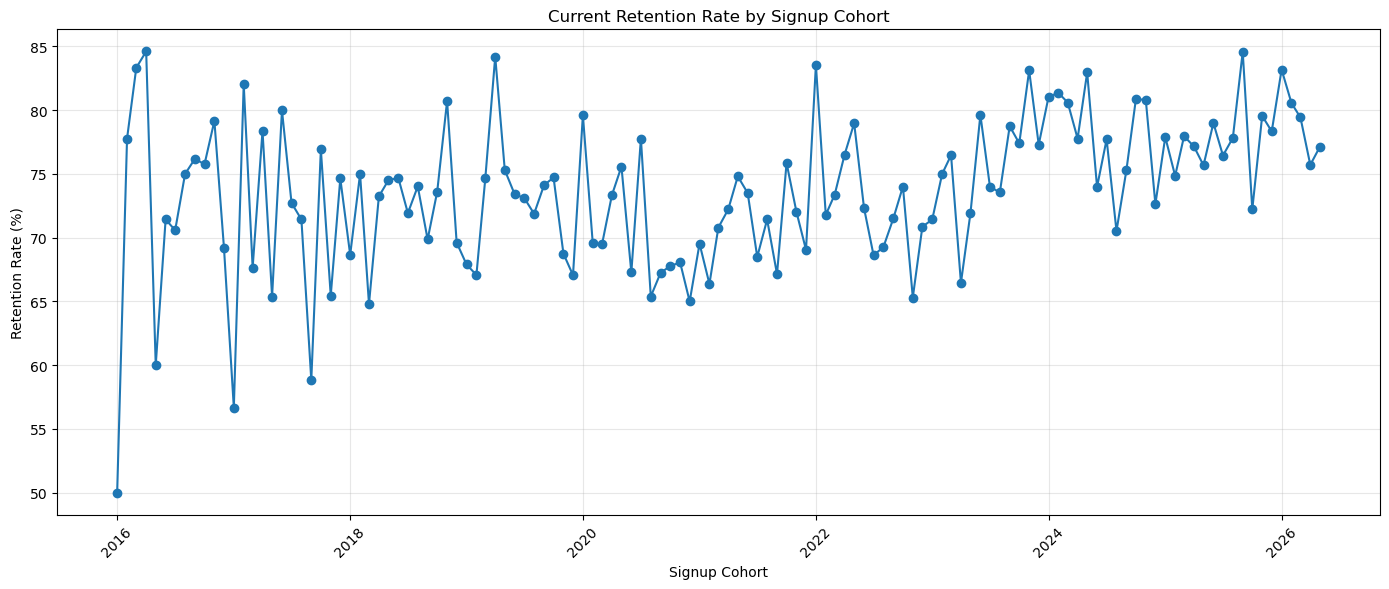

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    cohort_retention.index,
    cohort_retention.values,
    marker="o"
)

plt.title("Current Retention Rate by Signup Cohort")
plt.xlabel("Signup Cohort")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Observation

The current retention rates vary across signup cohorts, with most cohorts showing retention rates between approximately 65% and 85%.

Some earlier cohorts show lower retention rates, while several recent cohorts maintain retention above 75%.

The variation across cohorts indicates that subscriber retention differs depending on the signup cohort.

Note: This analysis represents current retention by signup cohort based on the available `is_active` status. It does not represent month-by-month retention after signup because historical monthly activity data is not available in the subscriber dataset.